In [1]:
import pandas as pd
import numpy as np
from dython.nominal import associations
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# 'Malgun Gothic' 폰트를 기본으로 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_parquet('1.회원정보_train.parquet')
df1 = pd.read_parquet('4.청구입금정보_train.parquet')

In [3]:
df = df['Segment']

df2 = pd.concat([df, df1], axis = 1)

df2.head()

,Segment,기준년월,ID,대표결제일,대표결제방법코드,대표청구지고객주소구분코드,대표청구서수령지구분코드,청구서수령방법,청구서발송여부_B0,청구서발송여부_R3M,...,할인금액_청구서_B0M,상환개월수_결제일_R6M,상환개월수_결제일_R3M,선결제건수_R6M,선결제건수_R3M,연체건수_R6M,연체건수_R3M,혜택수혜금액_R3M,포인트_마일리지_환산_B0M,혜택수혜금액
0,D,201807,TRAIN_000000,27,자동이체,미확인,당사페이앱+이메일,문자메세지,1,1,...,0,5,3,0,0,1,0,3,0,0
1,E,201807,TRAIN_000001,13,자동이체,주거지,우편,우편,1,1,...,163,6,3,0,0,0,0,0,0,0
2,C,201807,TRAIN_000002,1,자동이체,미확인,이메일,이메일,1,1,...,0,6,3,0,0,0,0,121,0,50
3,D,201807,TRAIN_000003,5,자동이체,주거지,우편,우편,1,1,...,0,5,3,2,0,0,0,3,0,2
4,E,201807,TRAIN_000004,13,자동이체,주거지,우편,우편,0,1,...,0,1,1,0,0,0,0,0,0,0


In [4]:
# LabelEncoder 하기

object_col = ['ID','대표결제방법코드','대표청구지고객주소구분코드','대표청구서수령지구분코드','청구서수령방법','할인건수_R3M','할인건수_B0M','Segment']

le = LabelEncoder()

for col in object_col:
    df2[col] = le.fit_transform(df2[col].astype(str))

In [5]:
# 피어슨 상관계수 구하기

correlations = df2.corr()["Segment"].sort_values(ascending=False)

In [24]:
significant_corr = correlations[correlations.abs() >= 0.4]
print(significant_corr)

Segment     1.000000
청구금액_B0    -0.577988
청구금액_R3M   -0.590678
청구금액_R6M   -0.597904
Name: Segment, dtype: float64


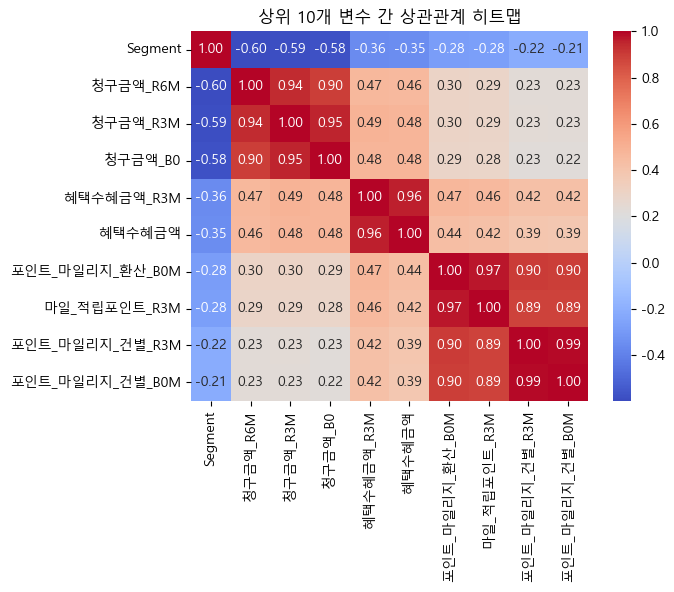

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Segment와 관련 있는 상위 10개 변수만 선택
top_features = correlations.abs().sort_values(ascending=False).head(10).index
sns.heatmap(df2[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("상위 10개 변수 간 상관관계 히트맵")
plt.show()